In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data=sns.load_dataset("titanic")


#Preprocessing

In [3]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
data.shape

(891, 15)

In [5]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [6]:
data.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


#Filling missing values

In [11]:
from sklearn.impute import SimpleImputer
imp_med=SimpleImputer(strategy="median")
data[["age"]]=imp_med.fit_transform(data[["age"]])
imp_freq=SimpleImputer(strategy="most_frequent")
data[["embarked"]]=imp_freq.fit_transform(data[["embarked"]])

In [12]:
data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


#Label Encoding

In [14]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
data["sex"]=le.fit_transform(data["sex"])
data["embarked"]=le.fit_transform(data["embarked"])


In [15]:
features=["pclass","sex","age","sibsp","parch","fare","embarked"	]
target=["survived"]
X=data[features]
y=data[target]

#Train Test Split

In [18]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

#Decision Tree Without Pruning

In [19]:
#Decision Tree without Pruning
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)
y_test_pred=dt.predict(X_test)
y_train_pred=dt.predict(X_train)

In [20]:
from sklearn.metrics import accuracy_score
print("Train accuracy",accuracy_score(y_train,y_train_pred))
print("Test accuracy",accuracy_score(y_test,y_test_pred))
#overfitting has occured

Train accuracy 0.9803370786516854
Test accuracy 0.7877094972067039


In [54]:
#Decision Tree with prePruning
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier(max_depth=5,min_samples_split=34)
dt.fit(X_train,y_train)
y_test_pred=dt.predict(X_test)
y_train_pred=dt.predict(X_train)
from sklearn.metrics import accuracy_score
print("Train accuracy",accuracy_score(y_train,y_train_pred))
print("Test accuracy",accuracy_score(y_test,y_test_pred))


Train accuracy 0.8356741573033708
Test accuracy 0.7877094972067039


#Plotting Decision Tree

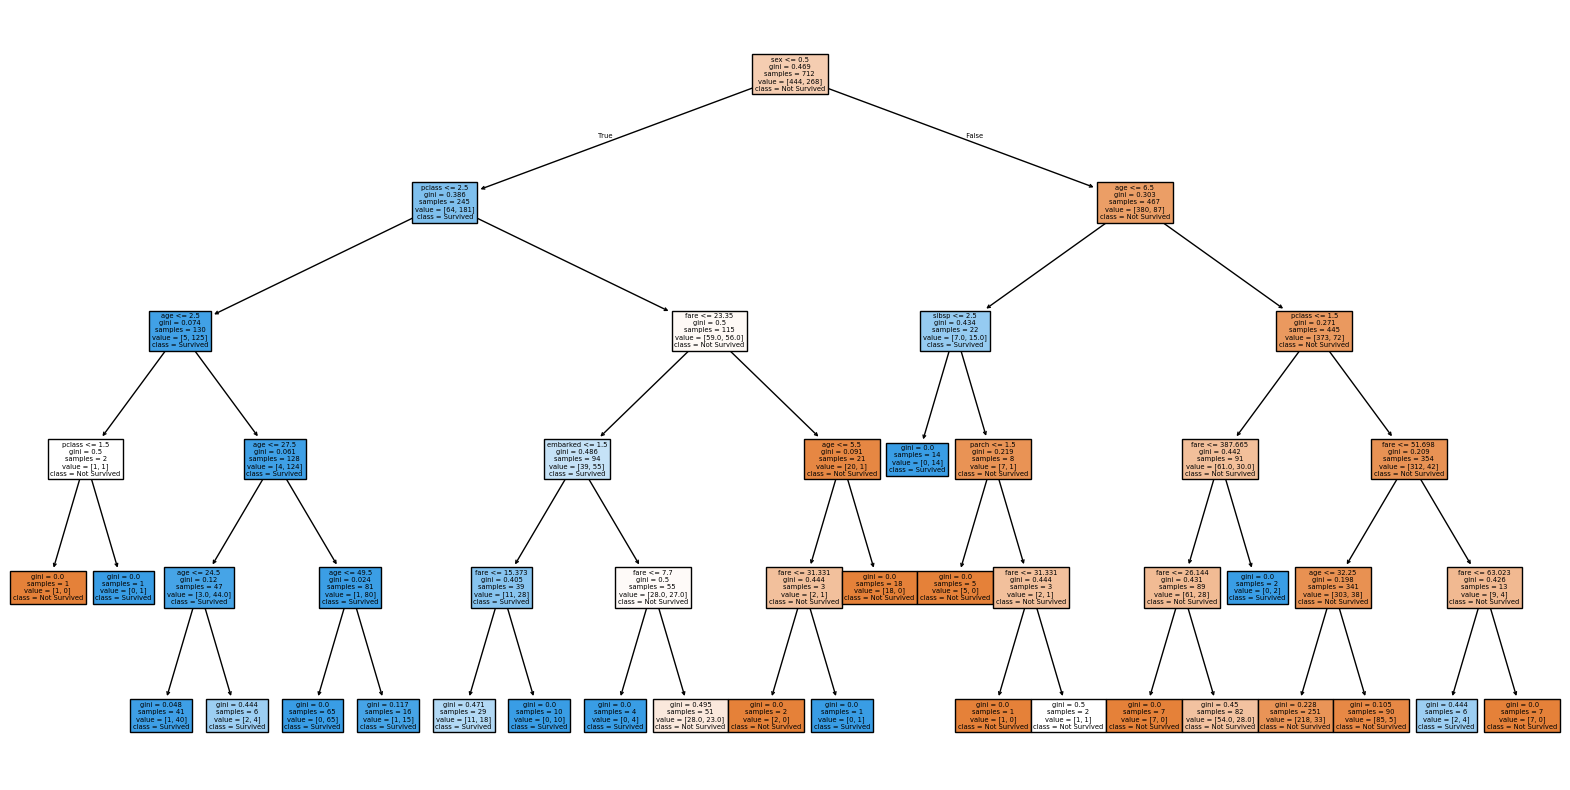

In [41]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree=plot_tree(dt,filled=True,class_names=["Not Survived","Survived"],feature_names=X.columns)

In [42]:
y_test_pred

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 1, 0])

#Implementing Random Forest

In [43]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=401,oob_score=True)
rf.fit(X_train,y_train)
y_test_pred=rf.predict(X_test)
y_train_pred=rf.predict(X_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [44]:
print("OOB score",rf.oob_score_)
print("Train accuracy",accuracy_score(y_train,y_train_pred))
print("Test accuracy",accuracy_score(y_test,y_test_pred))

OOB score 0.797752808988764
Train accuracy 0.9803370786516854
Test accuracy 0.8100558659217877


In [38]:
data.shape

(891, 15)

#Bagging Classifiers

In [56]:
# Using Decision Tree
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
base_dt=DecisionTreeClassifier()
bc=BaggingClassifier(base_dt,n_estimators=201,oob_score=True)
bc.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=201,
                  oob_score=True)

In [57]:
y_pred=bc.predict(X_test)
y_pred=bc.predict(X_train)
print("OOB score",bc.oob_score_)
print("Train accuracy",accuracy_score(y_train,y_train_pred))
print("Test accuracy",accuracy_score(y_test,y_test_pred))

OOB score 0.7907303370786517
Train accuracy 0.8356741573033708
Test accuracy 0.7877094972067039


In [60]:
from sklearn.linear_model import LogisticRegression
base_lr=LogisticRegression(max_iter=1000)
bc=BaggingClassifier(base_lr,n_estimators=201,oob_score=True)
bc.fit(X_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


BaggingClassifier(estimator=LogisticRegression(max_iter=1000), n_estimators=201,
                  oob_score=True)

In [62]:
y_pred=bc.predict(X_test)
y_pred=bc.predict(X_train)
print("OOB score",bc.oob_score_)
print("Train accuracy",accuracy_score(y_train,y_train_pred))
print("Test accuracy",accuracy_score(y_test,y_test_pred))

OOB score 0.797752808988764
Train accuracy 0.8356741573033708
Test accuracy 0.7877094972067039
